# ValoraCasa - Evidencia del proceso lógico de la Secci?n 13


## 1. Librerias

In [ ]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)

BASE = Path.cwd()
OUTDIR = BASE / "resultados_seccion_13"
FIGDIR = OUTDIR / "figuras"
OUTDIR.mkdir(exist_ok=True)
FIGDIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Carga del CSV de predicciones

In [ ]:
pred_path = BASE / "predicciones_valoracasa basados en los 3 modelos.csv"
pred = pd.read_csv(pred_path)

print("Dimensiones del CSV de predicciones:", pred.shape)
display(pred.head())
print("Columnas:")
print(pred.columns.tolist())

Dimensiones del CSV de predicciones: (2291, 9)


,ID,renta_real,pred_lineal_pesos,pred_rf_pesos,pred_xgb_pesos,pred_lineal_log,pred_rf_log,pred_xgb_log,renta_real_log
0,Hogar_1,"1,500.0000","1,525.8805","1,557.1967","1,529.1919",7.3310,7.3513,7.3331,7.3139
1,Hogar_2,"8,300.0000","3,717.2182","6,183.7719","5,645.5156",8.2210,8.7298,8.6388,9.0241
2,Hogar_3,"4,000.0000","2,190.6305","2,317.6300","2,426.7060",7.6924,7.7487,7.7947,8.2943
3,Hogar_4,"1,500.0000","1,282.4055","1,235.6730","1,314.8889",7.1573,7.1202,7.1823,7.3139
4,Hogar_5,800.0000,"1,990.3049","1,817.5207","1,466.0830",7.5965,7.5058,7.2910,6.6859


Columnas:
['ID', 'renta_real', 'pred_lineal_pesos', 'pred_rf_pesos', 'pred_xgb_pesos', 'pred_lineal_log', 'pred_rf_log', 'pred_xgb_log', 'renta_real_log']


## 3. Metricas



In [ ]:
models = [
    ("Regresión Lineal", "pred_lineal_pesos", "pred_lineal_log"),
    ("Random Forest", "pred_rf_pesos", "pred_rf_log"),
    ("XGBoost", "pred_xgb_pesos", "pred_xgb_log"),
]

metric_rows = []
for name, pesos_col, log_col in models:
    y = pred["renta_real"]
    y_hat = pred[pesos_col]
    y_log = pred["renta_real_log"]
    y_hat_log = pred[log_col]

    err = y_hat - y
    abs_err = err.abs()
    ape = abs_err / y * 100

    metric_rows.append({
        "Modelo": name,
        "R2_log": r2_score(y_log, y_hat_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_log, y_hat_log)),
        "MAE_pesos": mean_absolute_error(y, y_hat),
        "RMSE_pesos": np.sqrt(mean_squared_error(y, y_hat)),
        "MedAE_pesos": median_absolute_error(y, y_hat),
        "MAPE_%": ape.mean(),
        "MdAPE_%": ape.median(),
        "Error_medio_pesos": err.mean(),
        "Sobreestima_%": (err > 0).mean() * 100,
        "Dentro_500_%": (abs_err <= 500).mean() * 100,
        "Dentro_1000_%": (abs_err <= 1000).mean() * 100,
    })

metricas = pd.DataFrame(metric_rows)
display(metricas.round(4))

,Modelo,R2_log,RMSE_log,MAE_pesos,RMSE_pesos,MedAE_pesos,MAPE_%,MdAPE_%,Error_medio_pesos,Sobreestima_%,Dentro_500_%,Dentro_1000_%
0,Regresión Lineal,0.6163,0.4075,940.1310,"1,525.0598",566.6206,34.2113,24.8230,-234.1034,48.6687,45.9188,70.9734
1,Random Forest,0.6569,0.3854,865.6445,"1,373.0254",532.4387,32.1285,23.2156,-220.8527,47.9267,47.4902,73.2868
2,XGBoost,0.6753,0.3749,837.7938,"1,335.5823",504.5105,30.7819,22.4500,-204.8277,47.8394,49.5853,74.8145


### Lectura de las m?tricas

El mejor desempeño general corresponde a **XGBoost**:

- mayor `R2_log` en prueba: aproximadamente **0.6753**;
- menor `RMSE_log`: aproximadamente **0.3749**;
- menor `MAE` en pesos: aproximadamente **$838**;
- menor `RMSE` en pesos: aproximadamente **$1,336**;
- mayor porcentaje dentro de $1,000: aproximadamente **74.8%**.

Esto significa que XGBoost fue el modelo mas preciso en el conjunto de prueba y, ademas, el mas conveniente para comunicar una renta sugerida en el dashboard.

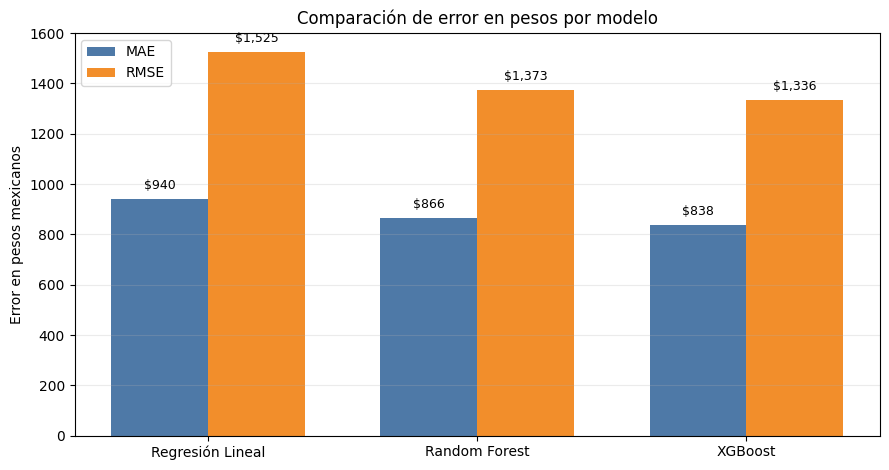

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(metricas))

ax.bar(x - 0.18, metricas["MAE_pesos"], width=0.36, label="MAE", color="#4E79A7")
ax.bar(x + 0.18, metricas["RMSE_pesos"], width=0.36, label="RMSE", color="#F28E2B")
ax.set_xticks(x)
ax.set_xticklabels(metricas["Modelo"])
ax.set_ylabel("Error en pesos mexicanos")
ax.set_title("Comparación de error en pesos por modelo")
ax.legend()
ax.grid(axis="y", alpha=0.25)

for i, row in metricas.iterrows():
    ax.text(i - 0.18, row["MAE_pesos"] + 40, f"${row['MAE_pesos']:,.0f}", ha="center", fontsize=9)
    ax.text(i + 0.18, row["RMSE_pesos"] + 40, f"${row['RMSE_pesos']:,.0f}", ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(FIGDIR / "comparacion_error_pesos.png", dpi=180)
plt.show()

## 4. Comprobacion de modelos

In [ ]:
train_test = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "XGBoost"],
    "R2_train": [0.6241, 0.8203, 0.8074],
    "R2_test": [0.6163, 0.6569, 0.6753],
    "RMSE_train_log": [0.4102, 0.2837, 0.2937],
    "RMSE_test_log": [0.4075, 0.3854, 0.3749],
})

display(train_test)

,Modelo,R2_train,R2_test,RMSE_train_log,RMSE_test_log
0,Regresi?n Lineal,0.6241,0.6163,0.4102,0.4075
1,Random Forest,0.8203,0.6569,0.2837,0.3854
2,XGBoost,0.8074,0.6753,0.2937,0.3749


In [ ]:
cv = pd.DataFrame({
    "Pliegue": ["Pliegue 1", "Pliegue 2", "Pliegue 3", "Pliegue 4", "Pliegue 5"],
    "Regresión Lineal": [0.5978, 0.6004, 0.6324, 0.6147, 0.6077],
    "Random Forest": [0.6258, 0.6339, 0.6665, 0.6696, 0.6537],
    "XGBoost": [0.6508, 0.6510, 0.6769, 0.6795, 0.6726],
})

cv_summary = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "XGBoost"],
    "R2_CV_Media": [0.6106, 0.6499, 0.6662],
    "R2_CV_Std": [0.0124, 0.0174, 0.0127],
    "R2_Test": [0.6163, 0.6569, 0.6753],
    "RMSE_Test_Log": [0.4075, 0.3854, 0.3749],
})

display(cv)
display(cv_summary)

,Pliegue,Regresión Lineal,Random Forest,XGBoost
0,Pliegue 1,0.5978,0.6258,0.6508
1,Pliegue 2,0.6004,0.6339,0.6510
2,Pliegue 3,0.6324,0.6665,0.6769
3,Pliegue 4,0.6147,0.6696,0.6795
4,Pliegue 5,0.6077,0.6537,0.6726


,Modelo,R2_CV_Media,R2_CV_Std,R2_Test,RMSE_Test_Log
0,Regresión Lineal,0.6106,0.0124,0.6163,0.4075
1,Random Forest,0.6499,0.0174,0.6569,0.3854
2,XGBoost,0.6662,0.0127,0.6753,0.3749


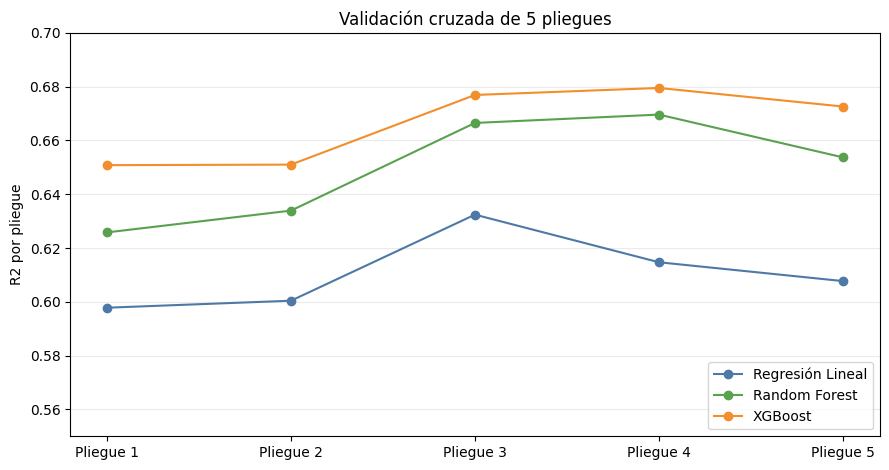

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(cv["Pliegue"], cv["Regresión Lineal"], marker="o", label="Regresión Lineal", color="#4E79A7")
ax.plot(cv["Pliegue"], cv["Random Forest"], marker="o", label="Random Forest", color="#59A14F")
ax.plot(cv["Pliegue"], cv["XGBoost"], marker="o", label="XGBoost", color="#F28E2B")
ax.set_ylim(0.55, 0.70)
ax.set_ylabel("R2 por pliegue")
ax.set_title("Validación cruzada de 5 pliegues")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGDIR / "validacion_cruzada_r2.png", dpi=180)
plt.show()

## 5. Error por rango de renta real

In [ ]:
bins = [0, 1000, 2000, 3000, 5000, 8000, 16000]
labels = [
    "<= $1,000",
    "$1,001-$2,000",
    "$2,001-$3,000",
    "$3,001-$5,000",
    "$5,001-$8,000",
    "$8,001-$16,000",
]

pred["rango_renta"] = pd.cut(pred["renta_real"], bins=bins, labels=labels, include_lowest=True)
range_rows = []

for label in labels:
    data = pred[pred["rango_renta"] == label]
    err = data["pred_xgb_pesos"] - data["renta_real"]
    range_rows.append({
        "Rango de renta real": label,
        "Registros": len(data),
        "Renta_media": data["renta_real"].mean(),
        "Prediccion_media": data["pred_xgb_pesos"].mean(),
        "MAE": err.abs().mean(),
        "Sesgo_medio": err.mean(),
        "Dentro_1000_%": (err.abs() <= 1000).mean() * 100,
    })

error_por_rango = pd.DataFrame(range_rows)
display(error_por_rango.round(2))

,Rango de renta real,Registros,Renta_media,Prediccion_media,MAE,Sesgo_medio,Dentro_1000_%
0,"<= $1,000",257,845.6800,"1,364.7700",543.2100,519.0900,87.9400
1,"$1,001-$2,000",813,"1,666.4200","1,890.2600",447.3300,223.8400,91.8800
2,"$2,001-$3,000",544,"2,676.8400","2,579.6500",620.6500,-97.1900,82.1700
3,"$3,001-$5,000",340,"3,893.8200","3,464.8600",945.9500,-428.9600,62.0600
4,"$5,001-$8,000",213,"5,893.3600","5,014.5000","1,584.2300",-878.8600,31.9200
5,"$8,001-$16,000",119,"10,292.4400","7,235.8100","3,230.3400","-3,056.6300",12.6100


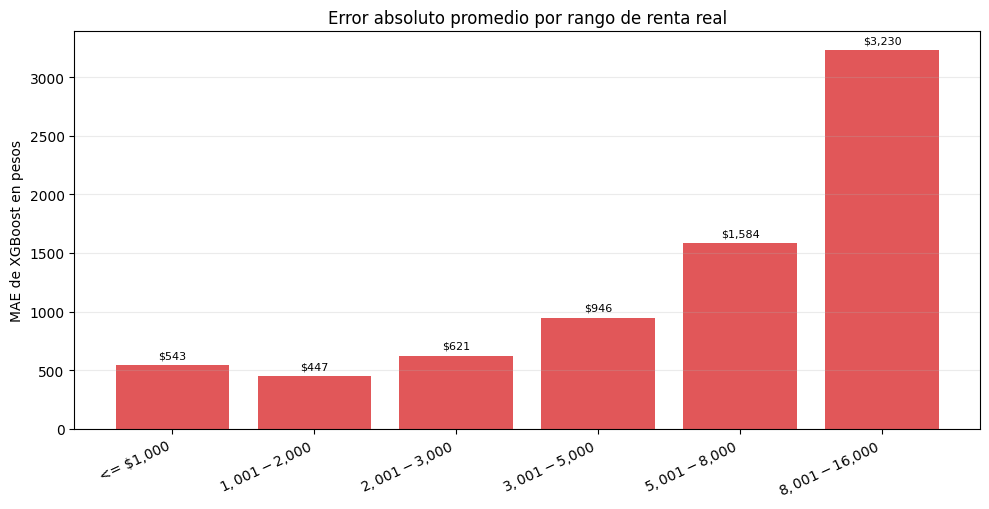

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(error_por_rango))
ax.bar(x, error_por_rango["MAE"], color="#E15759")
ax.set_xticks(x)
ax.set_xticklabels(error_por_rango["Rango de renta real"], rotation=25, ha="right")
ax.set_ylabel("MAE de XGBoost en pesos")
ax.set_title("Error absoluto promedio por rango de renta real")
ax.grid(axis="y", alpha=0.25)

for i, row in error_por_rango.iterrows():
    ax.text(i, row["MAE"] + 60, f"${row['MAE']:,.0f}", ha="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIGDIR / "error_por_rango_xgboost.png", dpi=180)
plt.show()

## 6. Reconstruccion del pipeline de XGBoost

In [ ]:
df_raw = pd.read_csv(BASE / "viviendas_limpio_valuacasa.csv")
print("Dataset limpio completo:", df_raw.shape)

df = df_raw[df_raw["renta"] > 0].copy()
print("Registros con renta > 0:", len(df))

p99 = df["renta"].quantile(0.99)
df = df[df["renta"] <= p99].copy()
print("Percentil 99 de renta:", p99)
print("Registros despues de quitar outliers:", len(df))

df["log_renta"] = np.log1p(df["renta"])

vars_1_2 = [
    "cocina", "lavadero", "fregadero", "regadera", "tinaco_azo",
    "cisterna", "pileta", "calent_sol", "calent_gas", "medid_luz",
    "bomba_agua", "tanque_gas", "aire_acond", "calefacc",
]

for var in vars_1_2:
    df[var] = df[var].map({1: 1, 2: 0})

vars_problemas = [
    "p_grietas", "p_pandeos", "p_levanta", "p_humedad",
    "p_fractura", "p_electric", "p_tuberias",
]

for var in vars_problemas:
    df[var] = df[var].map({1: 1, 2: 0, 9: 0})

renta_por_municipio = df.groupby("ubica_geo")["renta"].mean()
df["renta_media_municipio"] = df["ubica_geo"].map(renta_por_municipio)

print("Municipios unicos:", df["ubica_geo"].nunique())
print("Renta media municipal minima:", df["renta_media_municipio"].min())
print("Renta media municipal maxima:", df["renta_media_municipio"].max())

Dataset limpio completo: (90324, 50)
Registros con renta > 0: 11566
Percentil 99 de renta: 16000.0
Registros despues de quitar outliers: 11455
Municipios unicos: 763
Renta media municipal minima: 200.0
Renta media municipal maxima: 15000.0


In [ ]:
vars_ordinales = [
    "tam_loc", "est_socio", "dotac_agua", "focos", "num_cuarto",
    "cuart_dorm", "antiguedad", "bano_comp", "bano_excus", "bano_regad",
]

vars_nominales = [
    "tipo_viv", "mat_pared", "mat_techos", "mat_pisos",
    "lugar_coc", "agua_ent", "ab_agua", "sanit_agua",
    "excusado", "uso_compar", "drenaje", "disp_elect",
    "combus", "eli_basura",
]

vars_binarias = [
    "cocina", "lavadero", "fregadero", "regadera", "tinaco_azo",
    "cisterna", "pileta", "calent_sol", "calent_gas", "medid_luz",
    "bomba_agua", "tanque_gas", "aire_acond", "calefacc",
    "p_grietas", "p_pandeos", "p_levanta", "p_humedad",
    "p_fractura", "p_electric", "p_tuberias",
    "antiguedad_no_especificada",
]

vars_geograficas = ["renta_media_municipio"]
FEATURES = vars_ordinales + vars_nominales + vars_binarias + vars_geograficas
TARGET = "log_renta"

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=df["est_socio"],
)

print("Variables predictoras:", len(FEATURES))
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

pd.DataFrame({
    "Entrenamiento": X_train["est_socio"].value_counts(normalize=True).sort_index(),
    "Prueba": X_test["est_socio"].value_counts(normalize=True).sort_index(),
}).round(3)

Variables predictoras: 47
Entrenamiento: (9164, 47)
Prueba: (2291, 47)


,Entrenamiento,Prueba
est_socio,,
1,0.0910,0.0910
2,0.4790,0.4790
3,0.2910,0.2900
4,0.1400,0.1400


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), vars_ordinales),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), vars_nominales),
        ("passthrough", "passthrough", vars_binarias + vars_geograficas),
    ],
    remainder="drop",
)

pipe_xgb = Pipeline([
    ("prep", preprocessor),
    ("modelo", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )),
])

pipe_xgb.fit(X_train, y_train)

pred_train_log = pipe_xgb.predict(X_train)
pred_test_log = pipe_xgb.predict(X_test)

local_summary = {
    "R2_train": r2_score(y_train, pred_train_log),
    "R2_test": r2_score(y_test, pred_test_log),
    "RMSE_train_log": np.sqrt(mean_squared_error(y_train, pred_train_log)),
    "RMSE_test_log": np.sqrt(mean_squared_error(y_test, pred_test_log)),
    "MAE_test_pesos": mean_absolute_error(np.expm1(y_test), np.expm1(pred_test_log)),
}

local_summary

{'R2_train': 0.8052519909202925,
 'R2_test': 0.6780246488615185,
 'RMSE_train_log': np.float64(0.29529882030780863),
 'RMSE_test_log': np.float64(0.3732968393022959),
 'MAE_test_pesos': 828.4053491253566}

## 7. Importancia de variables

In [ ]:
feature_names = pipe_xgb.named_steps["prep"].get_feature_names_out()
importances = pipe_xgb.named_steps["modelo"].feature_importances_

raw_importance = pd.DataFrame({
    "feature_transformed": feature_names,
    "importance": importances,
})

original_names = []
for feature in raw_importance["feature_transformed"]:
    if feature.startswith("ordinal__"):
        original = feature.replace("ordinal__", "")
    elif feature.startswith("passthrough__"):
        original = feature.replace("passthrough__", "")
    elif feature.startswith("onehot__"):
        stripped = feature.replace("onehot__", "")
        original = next(
            (var for var in vars_nominales if stripped.startswith(var + "_")),
            stripped,
        )
    else:
        original = feature
    original_names.append(original)

raw_importance["variable"] = original_names

importance_grouped = (
    raw_importance
    .groupby("variable", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
importance_grouped["importance_pct"] = (
    importance_grouped["importance"] / importance_grouped["importance"].sum() * 100
)

display(importance_grouped.head(20).round(4))

,variable,importance,importance_pct
20,est_socio,0.1137,11.3746
41,sanit_agua,0.0907,9.0683
27,mat_pisos,0.0724,7.2404
23,fregadero,0.0677,6.7674
40,renta_media_municipio,0.0466,4.6616
10,calent_gas,0.0423,4.2259
28,mat_techos,0.0420,4.2010
14,combus,0.0408,4.0849
45,tipo_viv,0.0398,3.9810
0,ab_agua,0.0338,3.3783


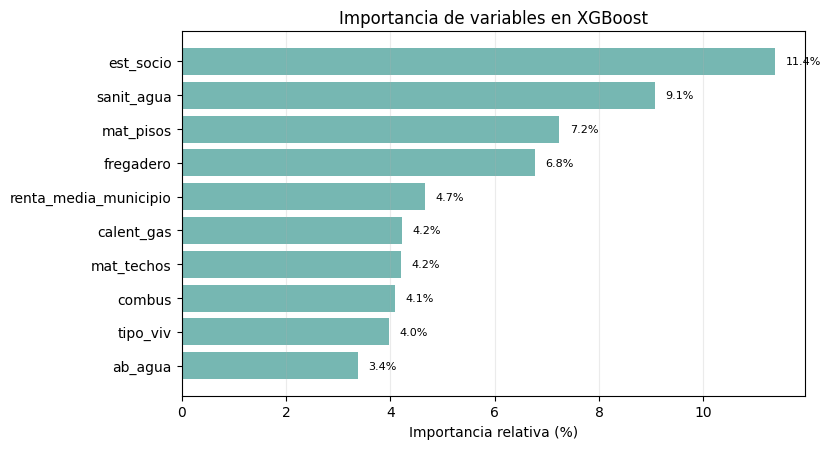

In [ ]:
imp_plot = importance_grouped.head(10).sort_values("importance_pct")

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.barh(imp_plot["variable"], imp_plot["importance_pct"], color="#76B7B2")
ax.set_xlabel("Importancia relativa (%)")
ax.set_title("Importancia de variables en XGBoost")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(imp_plot["importance_pct"]):
    ax.text(value + 0.2, i, f"{value:.1f}%", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIGDIR / "importancia_variables_xgboost.png", dpi=180)
plt.show()

## 8. Simulacion de factores que incrementan o reducen la renta

In [ ]:
def avg_pred_pesos(data):
    return float(np.expm1(pipe_xgb.predict(data)).mean())

selected_vars = [
    "renta_media_municipio", "focos", "est_socio", "calent_gas",
    "mat_pisos", "tanque_gas", "cisterna", "num_cuarto",
    "cuart_dorm", "regadera", "p_humedad", "p_grietas",
]

effect_rows = []
base_test = X_test.copy()

for var in selected_vars:
    values = sorted(base_test[var].dropna().unique())
    if set(values).issubset({0, 1}) and len(values) > 1:
        low, high = 0, 1
    else:
        low, high = base_test[var].quantile(0.25), base_test[var].quantile(0.75)

    low_df = base_test.copy()
    high_df = base_test.copy()
    low_df[var] = low
    high_df[var] = high

    pred_low = avg_pred_pesos(low_df)
    pred_high = avg_pred_pesos(high_df)

    effect_rows.append({
        "Variable": var,
        "Valor bajo": low,
        "Valor alto": high,
        "Prediccion baja": pred_low,
        "Prediccion alta": pred_high,
        "Diferencia promedio": pred_high - pred_low,
    })

effects = pd.DataFrame(effect_rows).sort_values("Diferencia promedio", ascending=False)
display(effects.round(2))

,Variable,Valor bajo,Valor alto,Prediccion baja,Prediccion alta,Diferencia promedio
0,renta_media_municipio,"2,064.4100","3,716.2300","2,197.6400","3,040.7700",843.1300
1,focos,4.0000,8.0000,"2,466.7000","2,907.1700",440.4700
2,est_socio,2.0000,3.0000,"2,423.8500","2,738.4200",314.5700
3,calent_gas,0.0000,1.0000,"2,673.8100","2,935.8900",262.0800
4,mat_pisos,2.0000,3.0000,"2,629.1900","2,881.3300",252.1400
5,tanque_gas,0.0000,1.0000,"2,788.0100","2,954.6100",166.6100
6,cisterna,0.0000,1.0000,"2,772.9700","2,908.8700",135.9000
7,num_cuarto,2.0000,4.0000,"2,720.6300","2,837.6300",117.0000
8,cuart_dorm,1.0000,2.0000,"2,751.9200","2,836.5000",84.5800
9,regadera,0.0000,1.0000,"2,789.7300","2,819.7800",30.0500


## 9. Seleccion del modelo final

Con base en las m?tricas, validaci?n y utilidad para el usuario final, el modelo seleccionado fue **XGBoost**.

La decisi?n se basa en:

- mejor `R2` en prueba;
- menor `RMSE` logar?tmico;
- menor `MAE` en pesos;
- mayor proporci?n de predicciones dentro de $1,000;
- capacidad para capturar relaciones no lineales entre variables de ubicaci?n, servicios, materiales y renta.

## 11. Guardado de evidencia generada

Esta celda guarda tablas de apoyo en CSV para que las metricas y resultados puedan revisarse fuera del notebook.

In [ ]:
metricas.to_csv(OUTDIR / "metricas_modelos.csv", index=False, encoding="utf-8-sig")
cv_summary.to_csv(OUTDIR / "validacion_cruzada_resumen.csv", index=False, encoding="utf-8-sig")
error_por_rango.to_csv(OUTDIR / "error_por_rango_xgboost.csv", index=False, encoding="utf-8-sig")
importance_grouped.head(20).to_csv(OUTDIR / "importancia_variables_xgboost.csv", index=False, encoding="utf-8-sig")
effects.to_csv(OUTDIR / "efectos_promedio_xgboost.csv", index=False, encoding="utf-8-sig")

print("Archivos guardados en:", OUTDIR)
print("Figuras guardadas en:", FIGDIR)

Archivos guardados en: d:\ValorCasa\Proyecto Analisis de Datos en la toma de decisiones\resultados_seccion_13
Figuras guardadas en: d:\ValorCasa\Proyecto Analisis de Datos en la toma de decisiones\resultados_seccion_13\figuras
